# **라이브러리 임포트**

In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow-addons
!pip install dataframe_image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 33.2 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.4
    Uninstalling typeguard-4.4.4:
      Successfully uninstalled typeguard-4.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 MB 49.5 MB/s eta 0:00:00


In [3]:
# 모델 분석 및 시각화 도구
import os
import math
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from PIL import Image
from collections import Counter
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.metrics import structural_similarity as ssim

# Scikit-learn (데이터 전처리 및 모델 평가)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import dataframe_image as dfi
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

# 데이터 증강 품질 검증
from skimage.metrics import structural_similarity as ssim


# 모델 설계
import tensorflow as tf
from keras import Model, regularizers
from keras.saving import register_keras_serializable


# 모델 구조 및 레이어
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D,
Flatten, Dropout, BatchNormalization, Embedding,
LeakyReLU, GlobalAveragePooling2D, Concatenate, concatenate)
from tensorflow.keras.layers import Layer, Lambda, Add, Activation, Multiply

# 사전 훈련된 모델
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2, MobileNetV3Small, VGG16, InceptionV3, Xception, DenseNet121

# 컴파일 및 훈련 관련
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalFocalCrossentropy

# **함수 정의**

In [4]:
# 좌표 연속형 특징 반환 함수
def build_cont_features(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm, eps=1e-6):      # 입력 : CSV 파일의 좌표 정보

    # 웨이퍼 중심 기준 결함의 상대 좌표
    dx = xc - wafer_cx
    dy = yc - wafer_cy

    # 반경 정규화(0~1)
    dist_norm = np.sqrt(dx*dx + dy*dy)    # 좌표 간 거리
    r_norm = np.clip(dist_norm / max(wafer_r_norm, eps), 0.0, 1.0)    # 정규화

    # 각도(라디안) 및 sin/cos
    theta = np.arctan2(dy, dx)    # 웨이퍼 중심 기준 결함의 방향
    sin_th = np.sin(theta)        # sin 변환
    cos_th = np.cos(theta)        # cos 변환

    # 파생특징
    area_norm   = bw * bh                           # 결함의 상대적 크기
    aspect_log  = np.log((bw + eps) / (bh + eps))   # 결함의 종횡비
    edge_margin = 1.0 - r_norm                      # 결함과 가장자리간 거리

    # 중심좌표를 [-1,1] 범위로 스케일(반지름 기준)
    x_centered = np.clip((dx / max(wafer_r_norm, eps)), -1.5, 1.5)
    y_centered = np.clip((dy / max(wafer_r_norm, eps)), -1.5, 1.5)

    # 연속형 특징 저장 (중심 좌표의 x y 좌표, 바운딩 박스의 높이밑변, 반지름, sin cos 각도, 상대적 크기, 종횡비, 가장자리간 거리)
    cont = np.array([
        x_centered, y_centered, bw, bh,
        r_norm, sin_th, cos_th, area_norm,
        aspect_log, edge_margin
    ], dtype=np.float32)

    # 출력
    return cont, r_norm, theta

# 좌표값 검증 함수 (0~1 이외의 좌표 값을 재설정)
def validate_coordinates(xc, yc, bw, bh):
    xc = np.clip(xc, 0.0, 1.0)
    yc = np.clip(yc, 0.0, 1.0)
    bw = np.clip(bw, 1e-6, 1.0) # 너비가 0이 되지 않도록
    bh = np.clip(bh, 1e-6, 1.0) # 높이가 0이 되지 않도록
    return xc, yc, bw, bh

# 증강 이미지 품질 검증 함수
def validate_augmentation(original_img, augmented_img, min_ssim=0.7):

    # 이미지를 흑백으로 변환하여 구조적 유사도만 비교
    orig_gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
    aug_gray = cv2.cvtColor(augmented_img, cv2.COLOR_RGB2GRAY)

    # 원본 이미지가 uint8 (0~255)이므로, data_range를 255 설정
    score, _ = ssim(orig_gray, aug_gray, full=True, data_range=255)

    # 점수가 기준치 이상이면 유효한 증강으로 판단
    return score >= min_ssim

# 데이터 로드 함수
def load_original_dataset(csv_path, image_root, image_size, fallback_bins=(8,16)):

    # 좌표값이 들어 있는 CSV 파일 불러오기
    df = pd.read_csv(csv_path)

    # 정보 저장
    info = ['class','cropped_image','x_center_norm','y_center_norm','width_norm','height_norm']

    # 오류 검증
    for c in info:
        if c not in df.columns:
            raise ValueError(f"CSV에 '{c}' 컬럼이 필요합니다.")

    # 웨이퍼 중심 좌표 저장
    has_wafer = all(c in df.columns for c in ['wafer_cx_norm','wafer_cy_norm','wafer_r_norm'])

    # 리스트 생성
    images, cont_list, rad_bins, sec_bins, labels = [], [], [], [], []

    # 좌표 정보 리스트 생성
    base_coords = []  # (xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm)


    N_RAD, N_SEC = fallback_bins

    # 결함 패턴에 대한 정보 수집
    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        img_path = os.path.join(image_root, row['class'], row['cropped_image'])
        img = cv2.imread(img_path)
        if img is None:
            print(f"경고: 이미지를 로드할 수 없습니다 - {img_path}")
            continue

        # 이미지 로드
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)

        # 좌표 정보 로드
        xc = float(row['x_center_norm'])    # 바운딩 박스 중심 x 좌표
        yc = float(row['y_center_norm'])    # 바운딩 박스 중심 y 좌표
        bw = float(row['width_norm'])       # 바운딩 박스 밑변
        bh = float(row['height_norm'])      # 바운딩 박스 높이
        wafer_cx = float(row['wafer_cx_norm']) if has_wafer else 0.5    # 웨이퍼 중심 x 좌표
        wafer_cy = float(row['wafer_cy_norm']) if has_wafer else 0.5    # 웨이퍼 중심 y 좌표
        wafer_rn = float(row['wafer_r_norm'])  if has_wafer else 0.5    # 웨이퍼의 반지름

        # 좌표 정보를 바탕으로 연속형 특징 추출
        cont, r_norm, theta = build_cont_features(xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn)

        # 범주형 특징 추출
        if 'rad_bin' in df.columns and 'sec_bin' in df.columns:
            rad_bin = int(row['rad_bin']); sec_bin = int(row['sec_bin'])
        else:
            rad_bin = int(np.clip(np.floor(r_norm * N_RAD), 0, N_RAD-1))
            two_pi = 2*np.pi
            sec_bin = int(np.floor(((theta % two_pi)/two_pi) * N_SEC))

        # 리스트에 저장
        images.append(img)        # Crop된 결함 패턴 이미지
        cont_list.append(cont)    # 연속형 특징
        rad_bins.append(rad_bin)  # 범주형 특징(동심원 구간)
        sec_bins.append(sec_bin)  # 범주형 특징(부채꼴 구간)
        labels.append(row['class'])   # 클래스 라벨링
        base_coords.append([xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn])   # 기본 좌표 정보

    print(f"-> 원본 데이터 로딩 완료: {len(images)}개 샘플")

    # 반환
    return (np.asarray(images, dtype=np.float32),
            np.asarray(cont_list, dtype=np.float32),
            np.asarray(rad_bins, dtype=np.int32),
            np.asarray(sec_bins, dtype=np.int32),
            np.asarray(labels),
            np.asarray(base_coords, dtype=np.float32))


# 연속형 특징 재계산 함수 ( 증강된 이미지에 대한 좌표 재계산)
def _recompute_cont_from_base(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_rn):
    cont, r_norm, theta = build_cont_features(xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn)
    two_pi = 2*np.pi
    rad_bin = int(np.clip(np.floor(r_norm * 8), 0, 7))
    sec_bin = int(np.floor(((theta % two_pi)/two_pi) * 16))
    return cont, rad_bin, sec_bin


# 데이터 증강 함수
def augment_and_balance_data(
    images, cont_features, rad_bins, sec_bins, labels, base_coords,
    augment_params: dict,
    random_state=42
):
    labels_series = pd.Series(labels)
    class_counts = labels_series.value_counts()
    target_count = class_counts.max()
    print(f"-> 데이터 증강 목표 개수 (각 클래스별): {target_count}")

    # 최종 데이터를 담을 리스트 (원본 데이터로 초기화)
    X_img, X_cont, X_rbin, X_sbin, y = \
        list(images), list(cont_features), list(rad_bins), list(sec_bins), list(labels)

    # 데이터 증강 루프
    for cls, count in class_counts.items():
        if count >= target_count:
            continue

        # 소수 클래스에 대해서 목표 개수만큼 증강 시작
        needed = target_count - count
        original_indices = np.where(labels == cls)[0]
        print(f"클래스 '{cls}': {needed}개 증강 시작")

        augmented_count = 0
        while augmented_count < needed:
            idx = np.random.choice(original_indices)

            # 증강의 기반이 될 원본 데이터 선택
            original_image_for_aug = images[idx].copy()
            xc, yc, bw, bh, wcx, wcy, wrn = base_coords[idx]

            # 증강 작업을 수행할 이미지 변수 (원본 복사본으로 시작)
            augmented_img = original_image_for_aug.copy()

            # --- 좌우 반전 ---
            if np.random.rand() < augment_params.get('p_hflip', 0.0):
                augmented_img = np.flip(augmented_img, axis=1)
                xc = 1.0 - xc

            # --- 상하 반전 ---
            if np.random.rand() < augment_params.get('p_vflip', 0.0):
                augmented_img = np.flip(augmented_img, axis=0)
                yc = 1.0 - yc

            # --- 회전 ---
            if np.random.rand() < augment_params.get('p_rotate', 0.0):
                limit = augment_params.get('rotate_limit', 15)
                angle = np.random.uniform(-limit, limit)
                h, w = augmented_img.shape[:2]
                M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
                augmented_img = cv2.warpAffine(augmented_img, M, (w, h))

                angle_rad = np.radians(angle)
                x_shifted, y_shifted = xc - 0.5, yc - 0.5
                xc_new = x_shifted * np.cos(angle_rad) - y_shifted * np.sin(angle_rad)
                yc_new = x_shifted * np.sin(angle_rad) + y_shifted * np.cos(angle_rad)
                xc, yc = xc_new + 0.5, yc_new + 0.5

            # 증강된 좌표 유효성 검증
            xc, yc, bw, bh = validate_coordinates(xc, yc, bw, bh)

            # --- 밝기/대비 조절 ---
            if np.random.rand() < augment_params.get('p_brightness_contrast', 0.0):
                alpha = 1.0 + np.random.uniform(-0.2, 0.2)
                beta = 10 * np.random.uniform(-1, 1)
                # augmented_img에 적용하고 uint8로 변환
                augmented_img = np.clip(alpha * augmented_img.astype(np.float32) + beta, 0, 255).astype(np.uint8)

            # 증강된 이미지 품질 검증
            if not validate_augmentation(original_image_for_aug, augmented_img):
                continue

            # 변경된 좌표로 모든 파생 특징 재계산
            new_cont, new_rbin, new_sbin = _recompute_cont_from_base(xc, yc, bw, bh, wcx, wcy, wrn)

            # 증강된 데이터를 리스트에 추가
            X_img.append(augmented_img)
            X_cont.append(new_cont)
            X_rbin.append(new_rbin)
            X_sbin.append(new_sbin)
            y.append(cls)

            # 유효한 증강 샘플 카운트 증가
            augmented_count += 1

        print(f"-> 클래스 '{cls}' 증강 완료 (총 {target_count}개)\n")

    # 6. 최종 데이터를 NumPy 배열로 변환하고 섞기
    X_img, X_cont, X_rbin, X_sbin, y = shuffle(
        np.asarray(X_img, dtype=np.uint8),  # 이미지는 uint8로 변환 후 shuffle
        np.asarray(X_cont, dtype=np.float32),
        np.asarray(X_rbin, dtype=np.int32),
        np.asarray(X_sbin, dtype=np.int32),
        np.asarray(y),
        random_state=random_state
    )

    return X_img, X_cont, X_rbin, X_sbin, y


In [5]:
# 모델 학습 결과 시각화 함수
def plot_training_history(history, model_name):

  # 정확도 그래프
  plt.figure(figsize=(14, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f'{model_name} - Accuracy', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Accuracy', fontsize=12)
  plt.legend()
  plt.grid(True)

  # 손실 그래프
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'{model_name} - Loss', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

# 혼동 행렬 시각화 함수
def plot_confusion_matrix(y_true, y_pred_probs, class_names, normalize=False, title='Confusion Matrix'):

  # 확률을 최종 클래스 예측(인덱스)으로 변환
  y_pred_classes = np.argmax(y_pred_probs, axis=1)
  y_true_classes = np.argmax(y_true, axis=1)

  # normalize 옵션 설정
  if normalize:
    # 'true': 실제 라벨(행)을 기준으로 정규화
    cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
    fmt = '.2f' # 소수점 둘째 자리까지 표시
  else:
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    fmt = 'd' # 정수로 표시

  # 혼동 행렬 시각화
  plt.figure(figsize=(9, 8))
  sns.heatmap(
    cm,
    annot=True,
    fmt=fmt, # [개선 2] 포맷 변경
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
  )

  plt.xlabel('Predicted Class', fontsize=12)
  plt.ylabel('Actual Class', fontsize=12)
  plt.title(title, fontsize=15)
  plt.show()

# 모델 성능 평가 함수
def evaluate_model_performance(history, model, X_test, y_test, encoder, model_name):
  print(f"--- {model_name} 모델 성능 평가 ---")

  # --- 학습 과정 시각화 ---
  plot_training_history(history, model_name)

  # --- 예측 수행 ---

  # X_test가 딕셔너리일 경우를 대비하여 리스트로 변환
  if isinstance(X_test, dict):
    X_test_list = [X_test['image'], X_test['continuous'], X_test['radial_bin'], X_test['sector_bin']]
    y_pred_probs = model.predict(X_test_list)
  else:
    y_pred_probs = model.predict(X_test)

  # 라벨 변환
  y_true_classes = np.argmax(y_test, axis=1)
  y_pred_classes = np.argmax(y_pred_probs, axis=1)

  # --- 전체 성능 지표 출력 ---
  accuracy = accuracy_score(y_true_classes, y_pred_classes) # 정확도
  precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)  # 정밀도
  recall = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)  # 재현율
  f1 = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)  # F1-Score

  print("\n--- Overall Model Performance ---")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-Score: {f1:.4f}")

  # --- 클래스별 성능 지표 출력 (classification_report 사용) ---
  print("\n--- Performance by Class ---")
  print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

  # --- 혼동 행렬 시각화 ---
  plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title=f'{model_name} - Confusion Matrix')
  plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title=f'{model_name} - Normalized Confusion Matrix')

In [6]:
# Custom Keras Layer

# 특징 추출 레이어
@register_keras_serializable(package="wafer")   # 모델 직렬화 데코레이터
class Slice1D(Layer):
    def __init__(self, start, size, **kwargs):
        super().__init__(**kwargs)
        self.start = int(start)
        self.size = int(size)
        self.supports_masking = True
    def call(self, inputs):
        return inputs[:, self.start:self.start + self.size]
    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.size)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"start": self.start, "size": self.size})
        return cfg

# 로그 스케일러
@register_keras_serializable(package="wafer")
class SafeLog1p(Layer):
    """log1p(max(x, eps))"""
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = float(eps)
        self.supports_masking = True
    def call(self, x):
        x = tf.cast(x, tf.float32)
        return tf.math.log1p(tf.maximum(x, self.eps))
    def compute_output_shape(self, input_shape):
        return input_shape
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"eps": self.eps})
        return cfg

# 반경 인코더 (rad_bin을 받아서 중심으로부터의 거리 정보 변환)(3 -> 0.375)
@register_keras_serializable(package="wafer")
class RadialPos(Layer):
    """int bin -> float pos = bin/8.0"""
    def __init__(self, denom=8.0, **kwargs):
        super().__init__(**kwargs)
        self.denom = float(denom)
        self.supports_masking = True
    def call(self, x):
        return tf.cast(x, tf.float32) / self.denom
    def compute_output_shape(self, input_shape):
        return input_shape
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"denom": self.denom})
        return cfg

# 각도 변환기 (sec_bin을 받아서 위치의 방향 정보로 변환)
@register_keras_serializable(package="wafer")
class SectorAngle(Layer):
    """int bin -> angle rad = bin * (2π / sectors)"""
    def __init__(self, sectors=16, **kwargs):
        super().__init__(**kwargs)
        self.sectors = int(sectors)
        self.supports_masking = True
    def call(self, x):
        return tf.cast(x, tf.float32) * (2.0 * math.pi / float(self.sectors))
    def compute_output_shape(self, input_shape):
        return input_shape
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"sectors": self.sectors})
        return cfg

# Sin 특징 인코더 (sec_bin에 대한 y좌표 변환)
@register_keras_serializable(package="wafer")
class Sin(Layer):
    def call(self, x):
        return tf.sin(x)
    def compute_output_shape(self, input_shape):
        return input_shape

# Cos 특징 인코더 (sec_bin에 대한 x좌표 변환)
@register_keras_serializable(package="wafer")
class Cos(Layer):
    def call(self, x):
        return tf.cos(x)
    def compute_output_shape(self, input_shape):
        return input_shape

# **데이터 로드**

In [7]:
# 데이터 경로
dataset_path = "/content/drive/MyDrive/ACK2025_Wafer/YOLO/Defect_Pattern_CNN_Dataset"
zip_file_name = "Pattern_Image_Coordinated_Dataset_v6.zip"
unzipped_dataset_path = "Pattern_Image_Coordinated_Dataset_v6"

# Colab 로컬로 데이터셋 이동 및 복사
print("데이터셋을 Colab 로컬 환경으로 복사합니다...")

# 변수를 사용하여 파일 경로를 동적으로 생성
zip_file_path_in_drive = os.path.join(dataset_path, zip_file_name)
!cp "{zip_file_path_in_drive}" /content/
print("압축 해제를 시작합니다...")
!unzip -o -q /content/"{zip_file_name}" -d /content/
print("데이터셋 준비 완료.")

# 로컬 폴더 목록 확인
print("\n/content/ 폴더 내용 확인:")
!ls -l /content/

데이터셋을 Colab 로컬 환경으로 복사합니다...
압축 해제를 시작합니다...
데이터셋 준비 완료.

/content/ 폴더 내용 확인:
total 168728
drwx------  6 root root      4096 Aug 19 00:52 drive
drwxrwxrwx 10 root root      4096 Aug 15 07:57 Pattern_Image_Coordinated_Dataset_v6
-rw-------  1 root root 172761235 Aug 19 00:53 Pattern_Image_Coordinated_Dataset_v6.zip
drwxr-xr-x  1 root root      4096 Aug 15 13:35 sample_data


In [8]:
# 데이터셋 경로 설정 및 이미지 크기 조절
csv_path = os.path.join(dataset_path, "bbox_info_v6.csv")
image_root = os.path.join("/content/", unzipped_dataset_path)
image_size = (128, 128)

# 데이터 로드
images, cont_features, rad_bins, sec_bins, labels, base_coords = load_original_dataset(csv_path, image_root, image_size)

# 적용할 데이터 증강 기법과 확률을 딕셔너리로 정의
augment_parameters = {
  'p_hflip': 0.5,
  'p_vflip': 0.5,
  'p_rotate': 0.3,
  'rotate_limit': 15, # -15 ~ +15도 사이에서 회전
  'p_brightness_contrast': 0.4
}

# 증강 함수 호출
X_aug_img, X_aug_cont, X_aug_rbin, X_aug_sbin, y_aug = augment_and_balance_data(
images, cont_features, rad_bins, sec_bins, labels, base_coords, augment_params=augment_parameters)

X_train_final = {
    'image': X_aug_img,
    'continuous': X_aug_cont,
    'radial_bin': X_aug_rbin,
    'sector_bin': X_aug_sbin
}
y_train_final = y_aug

100%|██████████| 8001/8001 [00:17<00:00, 457.48it/s] 


-> 원본 데이터 로딩 완료: 8001개 샘플
-> 데이터 증강 목표 개수 (각 클래스별): 1582
클래스 'Center': 113개 증강 시작
-> 클래스 'Center' 증강 완료 (총 1582개)

클래스 'Edge-Loc': 168개 증강 시작
-> 클래스 'Edge-Loc' 증강 완료 (총 1582개)

클래스 'Scratch': 500개 증강 시작
-> 클래스 'Scratch' 증강 완료 (총 1582개)

클래스 'Edge-Ring': 612개 증강 시작
-> 클래스 'Edge-Ring' 증강 완료 (총 1582개)

클래스 'Random': 746개 증강 시작
-> 클래스 'Random' 증강 완료 (총 1582개)

클래스 'Donut': 1073개 증강 시작
-> 클래스 'Donut' 증강 완료 (총 1582개)

클래스 'Near-full': 1443개 증강 시작
-> 클래스 'Near-full' 증강 완료 (총 1582개)



In [9]:
# --- 사전 준비: 라벨 데이터를 모델 학습에 맞게 변환 ---
# 문자 라벨 -> 정수 라벨로 변환
encoder = LabelEncoder()
y_integer_labels = encoder.fit_transform(y_train_final)

# 정수 라벨 -> 원-핫 인코딩
y_categorical_labels = to_categorical(y_integer_labels)


# --- 데이터 분리 (Train/Test Split) ---
# 분리할 모든 입력 데이터와 라벨을 함수에 전달합니다.
X_img_train, X_img_test, \
X_cont_train, X_cont_test, \
X_rbin_train, X_rbin_test, \
X_sbin_train, X_sbin_test, \
y_train, y_test = train_test_split(
    X_train_final['image'],
    X_train_final['continuous'],
    X_train_final['radial_bin'],
    X_train_final['sector_bin'],
    y_categorical_labels,  # 분리할 라벨 데이터 (원-핫 인코딩된 형태)
    test_size=0.2,         # 20%: 테스트 데이터
    random_state=42,
    stratify=y_integer_labels  # 분포 유지를 위해서는 정수 라벨을 사용
)

# 딕셔너리 정리
X_train = {
    'image': X_img_train,
    'continuous': X_cont_train,
    'radial_bin': X_rbin_train,
    'sector_bin': X_sbin_train
}

X_test = {
    'image': X_img_test,
    'continuous': X_cont_test,
    'radial_bin': X_rbin_test,
    'sector_bin': X_sbin_test
}


# --- 분리 결과 확인 ---
print("데이터 분리 완료")
print(f"훈련 데이터 개수: {len(X_train['image'])}")
print(f"테스트 데이터 개수: {len(X_test['image'])}")

# 클래스 분포 확인
print("\n훈련 데이터셋의 클래스 분포:")
y_train_int_labels = np.argmax(y_train, axis=1)
print(pd.Series(encoder.inverse_transform(y_train_int_labels)).value_counts())

print("\n테스트 데이터셋의 클래스 분포:")
y_test_int_labels = np.argmax(y_test, axis=1)
print(pd.Series(encoder.inverse_transform(y_test_int_labels)).value_counts())

데이터 분리 완료
훈련 데이터 개수: 10124
테스트 데이터 개수: 2532

훈련 데이터셋의 클래스 분포:
Near-full    1266
Scratch      1266
Center       1266
Donut        1266
Edge-Loc     1265
Random       1265
Loc          1265
Edge-Ring    1265
Name: count, dtype: int64

테스트 데이터셋의 클래스 분포:
Edge-Ring    317
Edge-Loc     317
Loc          317
Random       317
Donut        316
Scratch      316
Near-full    316
Center       316
Name: count, dtype: int64


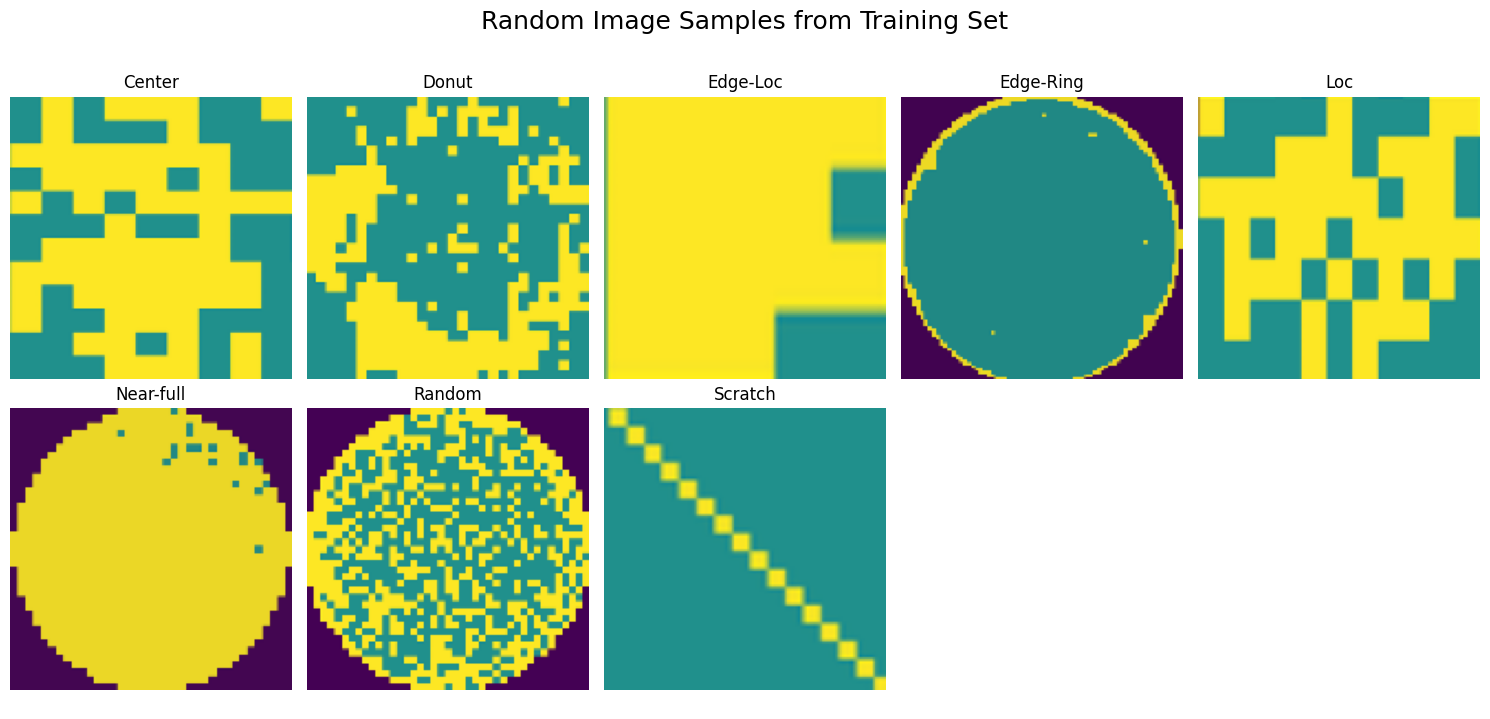

In [10]:
# 1. 클래스 정보 가져오기
unique_classes = encoder.classes_
num_classes = len(unique_classes)

# 2. 이미지를 출력할 격자(Grid) 설정
cols = 5
# 클래스 개수에 맞춰 행(row) 수를 자동으로 계산합니다.
rows = math.ceil(num_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
axes = axes.flatten() # 2D 배열을 1D로 만들어 쉽게 다룰 수 있게 함

# 3. 각 클래스별로 랜덤 이미지 출력
for i, class_name in enumerate(unique_classes):
    # 현재 클래스에 해당하는 정수 라벨 찾기
    class_code = encoder.transform([class_name])[0]

    # 훈련 세트에서 현재 클래스에 해당하는 모든 이미지의 인덱스를 찾습니다.
    indices_for_class = np.where(y_train_int_labels == class_code)[0]
    # 그 인덱스들 중에서 하나를 무작위로 선택합니다.
    random_index = np.random.choice(indices_for_class)

    # 선택된 랜덤 인덱스로 이미지를 가져옵니다.
    sample_image = X_train['image'][random_index]

    # 격자의 해당 위치(ax)에 이미지와 제목을 표시
    ax = axes[i]
    # .astype('uint8')을 추가하여 이미지를 올바른 형식으로 표시
    ax.imshow(sample_image.astype('uint8'))
    ax.set_title(class_name, fontsize=12)
    ax.axis('off') # 축 번호 숨기기

# 4. 사용되지 않은 빈 격자 숨기기
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Random Image Samples from Training Set', fontsize=18, y=1.02)
plt.tight_layout() # 이미지들이 겹치지 않게 자동 조절
plt.show()

# **모델 훈련**

## **6. MobileNetV3Small 전이학습**

In [11]:
# --- 모델 구성 ---

# 다중 입력층 정의 (이미지, 좌표 연속형 특징, 동심원 구간, 부채꼴 구간)
image_input = Input(shape=(128, 128, 3), name='image')    # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')  # 좌표 연속형 특징 입력
rad_bin_input = Input(shape=(1,), dtype='int32', name='radial_bin')    # 동심원 구간 입력
sec_bin_input = Input(shape=(1,), dtype='int32', name='sector_bin')    # 부채꼴 구간 입력


# --- 이미지 처리 브랜치 (MobileNetV3Small 전이학습 모델) ---
base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


# --- 연속형 특징 처리 브랜치 ---

# area 전처리 레이어
area_raw = Slice1D(7, 1, name='area_raw')(continuous_input) # area 특징만 추출
area_log = SafeLog1p(name='area_log')(area_raw)             # area 특징 로그 스케일

f_0_6 = Slice1D(0, 7, name='f_0_6')(continuous_input)   # x_center ~ cos_th 특징 추출
f_8   = Slice1D(8, 1, name='f_8')(continuous_input)     # aspect_ratio 특징만 추출
f_9   = Slice1D(9, 1, name='f_9')(continuous_input)     # confidence 특징만 추출
branch0 = Concatenate(name='cont_concat')([f_0_6, area_log, f_8, f_9])  # branch0 레이어로 통일

# 비선형 변환을 통한 고차원 특징 추출 (MLP)
branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

# 잔차 학습을 통한 정보 안정화 (Residual Block)
branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

# 명시적 특징 상호작용 (Manual Feature Cross)
r = Slice1D(4, 1, name='r_norm')(branch0)               # r_norm 특징만 추출
r_area = Multiply(name='r_times_area')([r, area_raw])   # r_norm과 area으로 Multiply 레이어 형성
sin_th = Slice1D(5, 1, name='sin_th')(branch0)          # sin_th 특징만 추출
cos_th = Slice1D(6, 1, name='cos_th')(branch0)          # cos_th 특징만 추출
angle_interaction = Multiply()([sin_th, cos_th])        # sin_th 특징과 cos_th 특징에 대한 Multiply 레이어 형성
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

# 하위 브랜치 통합
continuous_features = concatenate([branch1, branch2, branch3])

# --- 범주형 특징 처리 브랜치 ---

# 최적 임베딩 차원 계산 (rad, sec)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원


# 학습 기반 의미론적 임베딩(rad, sec)
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)
sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 임베딩 후 추가 처리 (rad, sec)
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)


# 기하학적 위치 인코딩 (pos)
rad_pos   = RadialPos(name='rad_pos')(rad_bin_input)     # rad_bin 에 대한 기하학적 위치 특징 추출
sec_angle = SectorAngle(name='sec_angle')(sec_bin_input) # sec_bin 에 대한 기하학적 위치 특징 추출
sec_sin   = Sin(name='sec_sin')(sec_angle)               # sec_bin 에 대한 y좌표 추출
sec_cos   = Cos(name='sec_cos')(sec_angle)               # sec_bin 에 대한 x좌표 추출

# 모든 기하학적 특징 레이어 통합 (pos)
pos_features = concatenate([rad_pos, sec_sin, sec_cos])
pos_encoded = Dense(8, activation='relu')(pos_features)


# 모든 범주형 특징 융합 ( rad, sec, pos )
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])



# --- 모든 좌표 정보 결합 ---

# 연속형 특징과 범주형 특징 통합
context_vector = concatenate([continuous_features, categorical_features])
context_vector = Dense(128, activation='relu')(context_vector) # 차원 조절 및 비선형성 추가

# 좌표 정보 바탕의 이미지 특징의 가중치 계산
attention_weights = Dense(128, activation='sigmoid', name='attention_weights')(context_vector)

# 이미지 특징에 좌표 정보 기반 어텐션 가중치 적용
attended_image_features = Multiply()([image_features, attention_weights])

# 최종 정보 결합 (어텐션 가중치가 적용된 이미지 특징 + 좌표 특징)
combined = concatenate([attended_image_features, context_vector])



# --- 최종 분류층 ---
M3 = Dense(64, activation='relu')(combined)
M3 = Dropout(0.5)(M3)
output = Dense(num_classes, activation='softmax', name='output')(M3)


# --- 최종 모델 생성 ---
model_mobilenetv3 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_mobilenetv3.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 전체 모델 구조 출력
model_mobilenetv3.summary()


# --- 모델 훈련 ---
history_mobilenetv3 = model_mobilenetv3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        256 │ expanded_conv_sq

 Total params: 1,064,792 (4.06 MB)

 Trainable params: 125,440 (490.00 KB)

 Non-trainable params: 939,352 (3.58 MB)

Epoch 1/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.2465 - loss: 0.3712 - val_accuracy: 0.7587 - val_loss: 0.1564
Epoch 2/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6149 - loss: 0.1639 - val_accuracy: 0.8310 - val_loss: 0.0747
Epoch 3/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7160 - loss: 0.1110 - val_accuracy: 0.8590 - val_loss: 0.0576
Epoch 4/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7786 - loss: 0.0901 - val_accuracy: 0.8665 - val_loss: 0.0527
Epoch 5/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8064 - loss: 0.0771 - val_accuracy: 0.8803 - val_loss: 0.0493
Epoch 6/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8218 - loss: 0.0726 - val_accuracy: 0.8859 - val_loss: 0.0470
Epoch 7/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8385 - loss: 0.0678 - val_accuracy: 0.8894 - val_loss: 0.0454
Epoch 8/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8510 - loss: 0.0613 - val_ac

--- MobileNetV3 Small 모델 성능 평가 ---


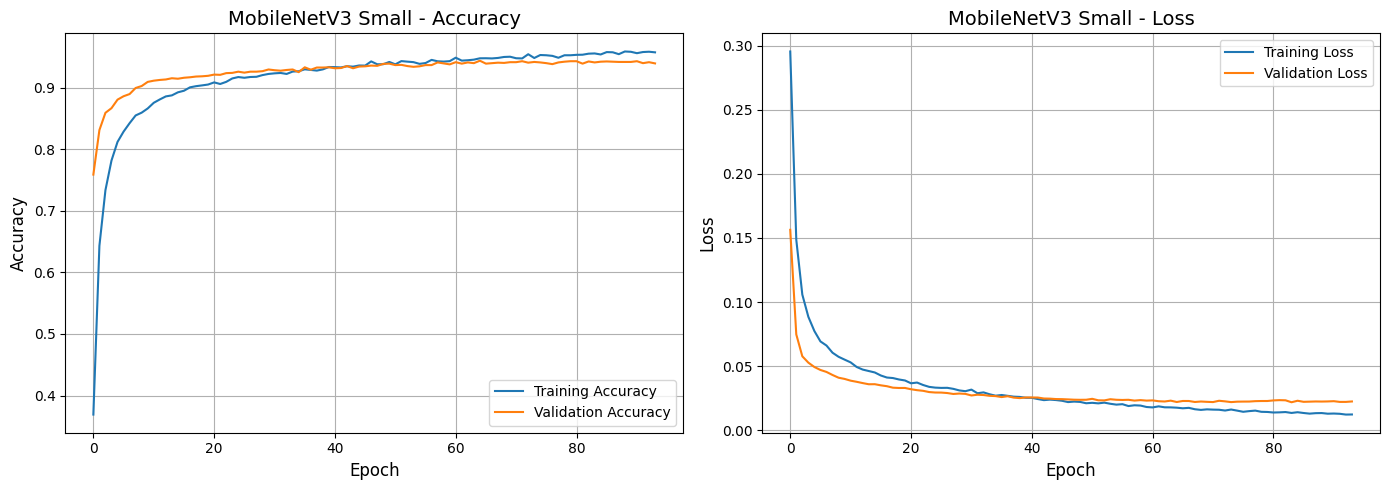

80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step

--- Overall Model Performance ---
Accuracy: 0.9408
Precision: 0.9405
Recall: 0.9408
F1-Score: 0.9400

--- Performance by Class ---
              precision    recall  f1-score   support

      Center       0.91      0.95      0.93       316
       Donut       0.95      0.99      0.97       316
    Edge-Loc       0.87      0.93      0.90       317
   Edge-Ring       0.99      0.99      0.99       317
         Loc       0.87      0.77      0.81       317
   Near-full       1.00      1.00      1.00       316
      Random       0.99      0.98      0.98       317
     Scratch       0.94      0.92      0.93       316

    accuracy                           0.94      2532
   macro avg       0.94      0.94      0.94      2532
weighted avg       0.94      0.94      0.94      2532



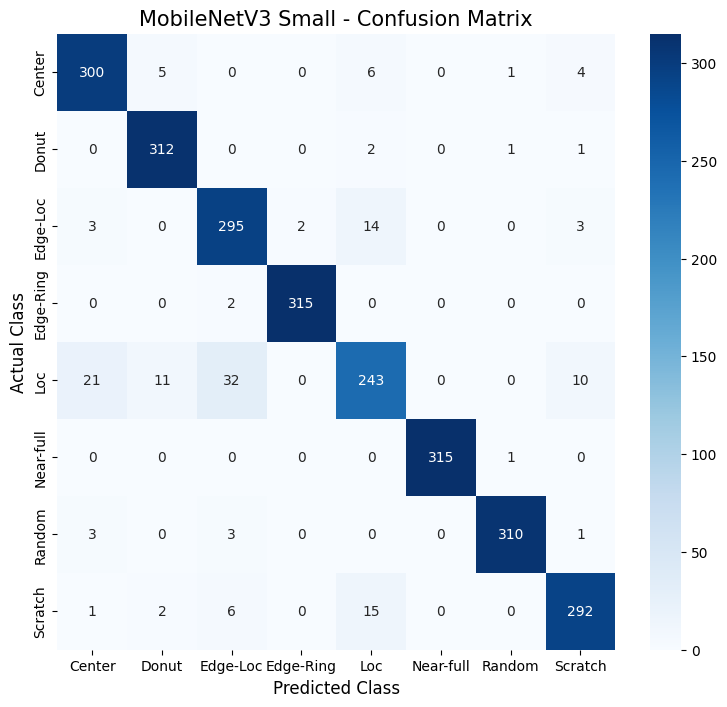

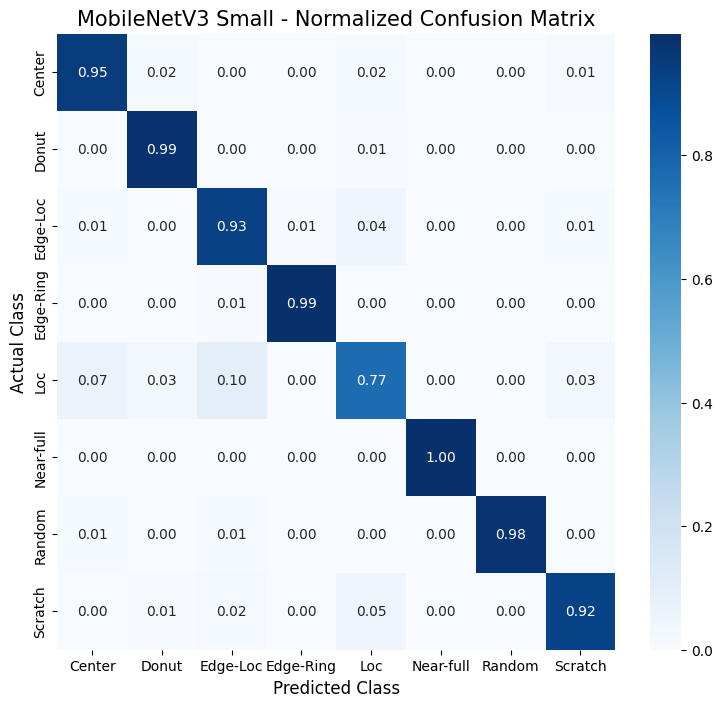

In [12]:
# 모델 평가
evaluate_model_performance(
  history_mobilenetv3,
  model_mobilenetv3,
  X_test,
  y_test,
  encoder,
  "MobileNetV3 Small"
)

## **7. ResNet50 전이학습**

In [13]:
# 다중 입력층 정의 (이미지, 좌표 연속형 특징, 동심원 구간, 부채꼴 구간)
image_input = Input(shape=(128, 128, 3), name='image')    # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')  # 좌표 연속형 특징 입력
rad_bin_input = Input(shape=(1,), dtype='int32', name='radial_bin')    # 동심원 구간 입력
sec_bin_input = Input(shape=(1,), dtype='int32', name='sector_bin')    # 부채꼴 구간 입력


# --- 이미지 처리 브랜치 (ResNet50 전이학습 모델) ---
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# ResNet50 모델의 출력에 새로운 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


# --- 연속형 특징 처리 브랜치 ---

# 전처리 레이어
area_raw = Slice1D(7, 1, name='area_raw')(continuous_input)
area_log = SafeLog1p(name='area_log')(area_raw)  # output_shape 자동

# branch0
f_0_6 = Slice1D(0, 7, name='f_0_6')(continuous_input)
f_8   = Slice1D(8, 1, name='f_8')(continuous_input)
f_9   = Slice1D(9, 1, name='f_9')(continuous_input)
branch0 = Concatenate(name='cont_concat')([f_0_6, area_log, f_8, f_9])

# Deep Feature
branch1 = Dense(64, activation='relu')(branch0)
branch1 = BatchNormalization()(branch1)
branch1 = Dropout(0.2)(branch1)
branch1 = Dense(32, activation='relu')(branch1)

# Residual Block
branch2 = Dense(32, activation='relu')(branch0)
branch2 = BatchNormalization()(branch2)
residual = Dense(32, activation=None)(branch0)  # 잔차
branch2 = Add()([branch2, residual])
branch2 = Activation('relu')(branch2)

# Feature Interaction
r = Slice1D(4, 1, name='r_norm')(branch0)
r_area = Multiply(name='r_times_area')([r, area_raw])
sin_th = Slice1D(5, 1, name='sin_th')(branch0)
cos_th = Slice1D(6, 1, name='cos_th')(branch0)
angle_interaction = Multiply()([sin_th, cos_th])
interactions = concatenate([r_area, angle_interaction])
branch3 = Dense(16, activation='relu')(interactions)

# 하위 브랜치 통합
continuous_features = concatenate([branch1, branch2, branch3])


# --- 범주형 특징 처리 브랜치 ---

# 최적 임베딩 차원 계산 (rad, sec)
rad_embed_dim = min(8, (8 // 2) + 1)  # 5차원
sec_embed_dim = min(12, (16 // 2) + 1)  # 9차원

# 정규화가 포함된 임베딩 (rad)
rad_embed = Embedding(
    input_dim=8,
    output_dim=rad_embed_dim,
    embeddings_regularizer=regularizers.l2(0.001),
    name='rad_embedding'
  )(rad_bin_input)
rad_flat = Flatten()(rad_embed)

# 정규화가 포함된 임베딩 (sec)
sec_embed = Embedding(
        input_dim=16,
        output_dim=sec_embed_dim,
        embeddings_regularizer=regularizers.l2(0.001),
        name='sec_embedding'
    )(sec_bin_input)
sec_flat = Flatten()(sec_embed)

# 위치 정보 보존을 위한 추가 특징
# 극좌표 특성을 고려한 위치 인코딩 (pos)
rad_pos   = RadialPos(name='rad_pos')(rad_bin_input)     # (None,1) 유지
sec_angle = SectorAngle(name='sec_angle')(sec_bin_input) # (None,1) 유지
sec_sin   = Sin(name='sec_sin')(sec_angle)
sec_cos   = Cos(name='sec_cos')(sec_angle)

pos_features = concatenate([rad_pos, sec_sin, sec_cos])  # 3차원
pos_encoded = Dense(8, activation='relu')(pos_features)

# 임베딩 후 추가 처리 (rad, sec)
rad_processed = Dense(8, activation='relu')(rad_flat)
rad_processed = BatchNormalization()(rad_processed)

sec_processed = Dense(12, activation='relu')(sec_flat)
sec_processed = BatchNormalization()(sec_processed)

# 모든 범주형 특징 융합 ( rad, sec, pos )
categorical_features = concatenate([rad_processed, sec_processed, pos_encoded])



# --- 모든 좌표 정보 결합 ---
context_vector = concatenate([continuous_features, categorical_features])
context_vector = Dense(128, activation='relu')(context_vector) # 차원 조절 및 비선형성 추가

# 좌표 정보 바탕의 이미지 특징의 가중치 계산
attention_weights = Dense(128, activation='sigmoid', name='attention_weights')(context_vector)

# 이미지 특징에 좌표 정보 기반 어텐션 가중치 적용
attended_image_features = Multiply()([image_features, attention_weights])

# 최종 정보 결합
combined = concatenate([attended_image_features, context_vector])



# 최종 분류층
RN50 = Dense(64, activation='relu')(combined)
RN50 = Dropout(0.5)(RN50)
output = Dense(num_classes, activation='softmax', name='output')(RN50)


# --- 최종 모델 생성 ---
model_resnet50 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_resnet50.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_resnet50.summary()


# --- 모델 훈련 ---
history_resnet50 = model_resnet50.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,901,800 (91.18 MB)

 Trainable params: 313,856 (1.20 MB)

 Non-trainable params: 23,587,944 (89.98 MB)

Epoch 1/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.3617 - loss: 0.3133 - val_accuracy: 0.7986 - val_loss: 0.1140
Epoch 2/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6806 - loss: 0.1404 - val_accuracy: 0.8649 - val_loss: 0.0633
Epoch 3/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7728 - loss: 0.0986 - val_accuracy: 0.8890 - val_loss: 0.0520
Epoch 4/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8214 - loss: 0.0772 - val_accuracy: 0.8930 - val_loss: 0.0479
Epoch 5/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8411 - loss: 0.0683 - val_accuracy: 0.8997 - val_loss: 0.0437
Epoch 6/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8539 - loss: 0.0612 - val_accuracy: 0.9068 - val_loss: 0.0420
Epoch 7/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8729 - loss: 0.0553 - val_accuracy: 0.9076 - val_loss: 0.0382
Epoch 8/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8581 - loss: 0

--- ResNet50 모델 성능 평가 ---


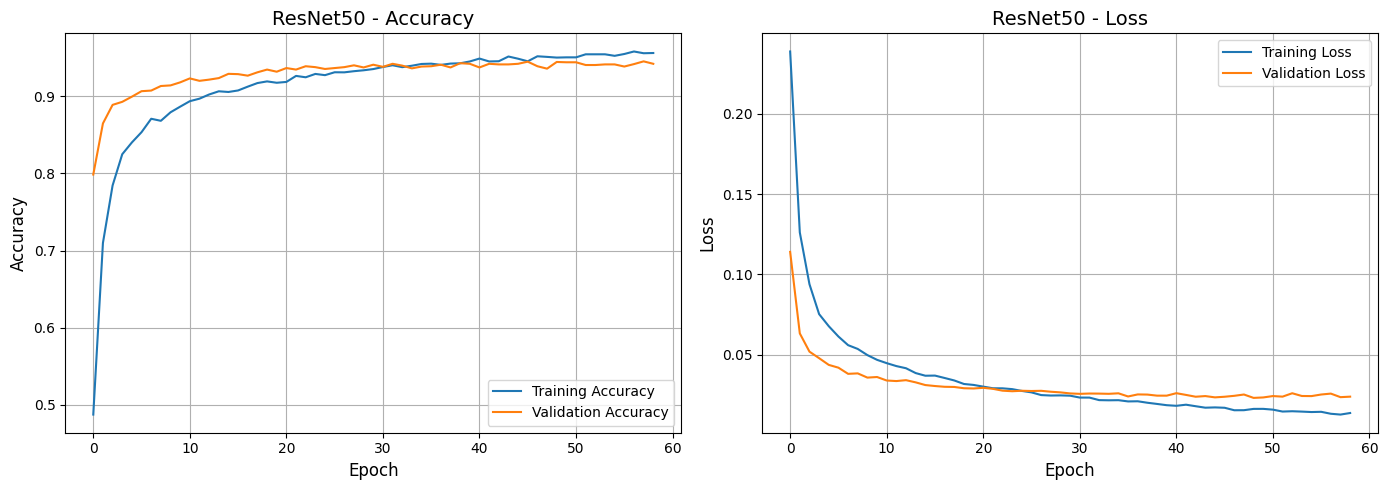

80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step

--- Overall Model Performance ---
Accuracy: 0.9447
Precision: 0.9444
Recall: 0.9447
F1-Score: 0.9444

--- Performance by Class ---
              precision    recall  f1-score   support

      Center       0.92      0.95      0.93       316
       Donut       0.94      0.96      0.95       316
    Edge-Loc       0.92      0.91      0.91       317
   Edge-Ring       0.99      0.99      0.99       317
         Loc       0.88      0.83      0.86       317
   Near-full       0.99      1.00      1.00       316
      Random       0.97      0.96      0.97       317
     Scratch       0.94      0.95      0.95       316

    accuracy                           0.94      2532
   macro avg       0.94      0.94      0.94      2532
weighted avg       0.94      0.94      0.94      2532



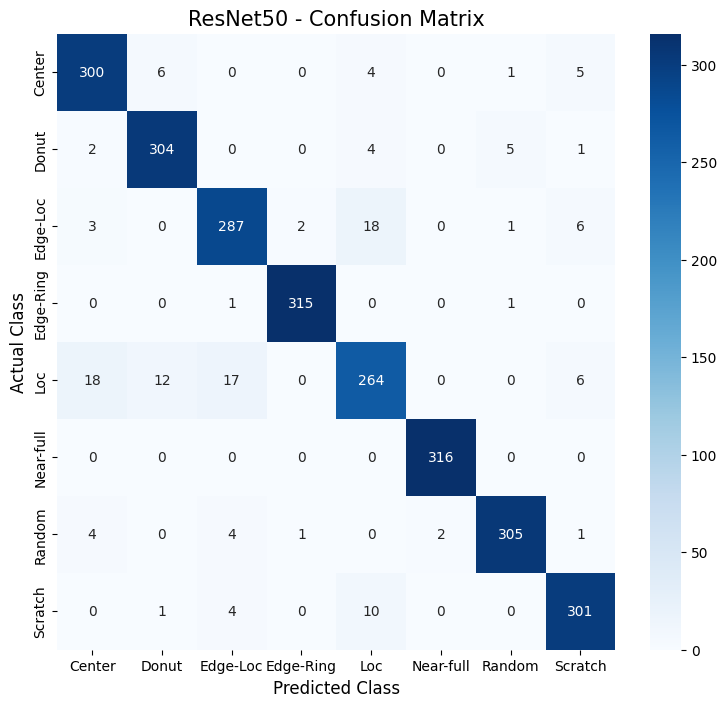

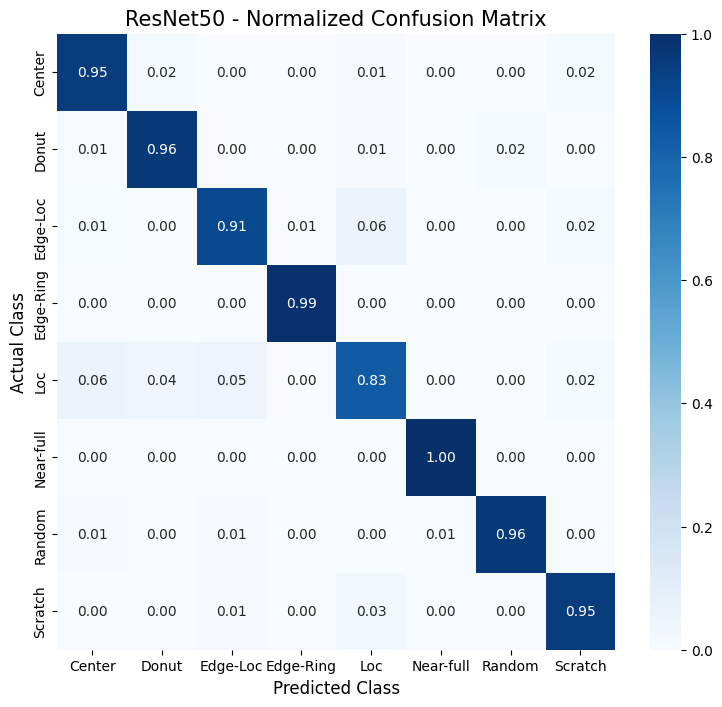

In [14]:
# 모델 평가
evaluate_model_performance(
  history_resnet50,
  model_resnet50,
  X_test,
  y_test,
  encoder,
  "ResNet50"
)

# **모델 저장**

In [15]:
import joblib
import tensorflow as tf

# --- 최고 성능의 모델 저장 ---
best_model = model_mobilenetv3
best_model.save("best_classifier_model.keras")

# --- 2번째 최고 성능의 모델 저장 ---
second_model = model_resnet50
second_model.save("second_classifier_model.keras")


print("최종 모델 저장 완료")

# --- LabelEncoder 저장 ---
joblib.dump(encoder, 'label_encoder.pkl')
print("라벨 인코더 저장 완료")

최종 모델 저장 완료
라벨 인코더 저장 완료


In [16]:
import joblib
import tensorflow as tf

# --- 저장할 디렉터리 생성 ---
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

# --- 최고 성능 모델 (MobileNetV3) 저장 ---
# 모델 구조(뼈대)를 JSON 파일로 저장
best_model_json = model_mobilenetv3.to_json()
with open(os.path.join(save_dir, "best_model_arch.json"), "w") as json_file:
    json_file.write(best_model_json)

# 모델 가중치(학습된 파라미터)를 H5 파일로 저장
model_mobilenetv3.save_weights(os.path.join(save_dir, "best_model.weights.h5"))

print("최고 성능 모델(MobileNetV3)의 구조와 가중치가 분리되어 저장되었습니다.")


# --- 2. 두 번째 최고 성능 모델 (ResNet50) 저장 ---
# 모델 구조(뼈대)를 JSON 파일로 저장
second_model_json = model_resnet50.to_json()
with open(os.path.join(save_dir, "second_model_arch.json"), "w") as json_file:
    json_file.write(second_model_json)

# 모델 가중치(학습된 파라미터)를 H5 파일로 저장
model_resnet50.save_weights(os.path.join(save_dir, "second_model.weights.h5"))

print("두 번째 최고 성능 모델(ResNet50)의 구조와 가중치가 분리되어 저장되었습니다.")


# --- 3. LabelEncoder 저장 ---
joblib.dump(encoder, os.path.join(save_dir, 'label_encoder.pkl'))
print("라벨 인코더가 저장되었습니다.")
print(f"\n모든 파일이 '{save_dir}/' 폴더에 저장되었습니다.")

최고 성능 모델(MobileNetV3)의 구조와 가중치가 분리되어 저장되었습니다.
두 번째 최고 성능 모델(ResNet50)의 구조와 가중치가 분리되어 저장되었습니다.
라벨 인코더가 저장되었습니다.

모든 파일이 'saved_models/' 폴더에 저장되었습니다.
